# **1. BiLSTM con embeddings Word2Vec**

El modelo **BiLSTM (Bidirectional Long Short-Term Memory)** con embeddings _Word2Vec_ combina la capacidad de representar el significado de las palabras con la habilidad de capturar dependencias contextuales en ambas direcciones del texto.

Primero, Word2Vec transforma cada palabra del vocabulario en un vector denso y continuo de tamaño fijo, donde palabras que aparecen en contextos similares tienen representaciones cercanas en el espacio vectorial. 

Luego, el BiLSTM procesa las secuencias de vectores palabra por palabra, pero a diferencia de una LSTM tradicional, lo hace en dos direcciones: una hacia adelante y otra hacia atrás, permitiendo que el modelo tenga en cuenta tanto el contexto previo como el posterior de cada término. De esta forma, el modelo no solo aprende la secuencia lingüística, sino también cómo el significado de cada palabra depende de su posición en la oración.

In [1]:
# [Librerias]

import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
np.random.seed(SEED)

import torch
torch.manual_seed(SEED)
device = torch.device("cpu")
print(f"Using device: {device}")

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,accuracy_score,confusion_matrix,f1_score
)
from gensim.models import Word2Vec

In [4]:
# MODULO DE MANEJO DE DATOS
# ---------------------------------

#  [Carga de datos]
df = pd.read_json('../Data/clean_words.json', lines=True)
df = df.rename(columns={'macro_label': 'Category'})
print(f"Registros totales: {len(df)}")

# Codificar etiquetas
le = LabelEncoder()
df["label"] = le.fit_transform(df["Category"])

# Dividir dataset
train, temp = train_test_split(df, test_size=0.3, random_state=SEED, stratify=df["label"])
val, test = train_test_split(temp, test_size=0.5, random_state=SEED, stratify=temp["label"])

print(f"Distribución de los datos: \nTrain: {len(train)} | Val: {len(val)} | Test: {len(test)}")

Registros totales: 2483
Distribución de los datos: 
Train: 1738 | Val: 372 | Test: 373


## 🔹Modelo

In [5]:
# MODULO DATASET PERSONALIZADO
# ---------------------------------

class Word2VecDataset(Dataset):
    """
    Dataset que convierte listas de tokens en embeddings de Word2Vec.
    Pad o truncamiento según sequence_length.
    """
    def __init__(self, df, w2v_model, sequence_length):
        self.data = df['tokens'].tolist()
        self.labels = df['label'].tolist()
        self.w2v_model = w2v_model
        self.sequence_length = sequence_length
        self.vector_size = w2v_model.vector_size

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        tokens = self.data[idx]
        embeddings = [self.w2v_model.wv[token] for token in tokens if token in self.w2v_model.wv]
        # Si no hay embeddings válidos, usar vector de ceros
        if len(embeddings) == 0:
            embeddings = [np.zeros(self.vector_size, dtype=np.float32)]
        # Padding o truncamiento
        if len(embeddings) < self.sequence_length:
            padding = np.zeros((self.sequence_length - len(embeddings), self.vector_size), dtype=np.float32)
            padded_embeddings = np.vstack((embeddings, padding))
        else:
            padded_embeddings = np.array(embeddings[:self.sequence_length], dtype=np.float32)

        input_tensor = torch.from_numpy(padded_embeddings)
        label_tensor = torch.tensor(self.labels[idx], dtype=torch.long)
        return input_tensor, label_tensor

In [ ]:
# MODULO MODELO 
# -------------------------

class BiLSTMClassifier(nn.Module):
    """
    Modelo BiLSTM:
    - Bidireccional
    - Dropout entre capas
    - Salida: número de clases
    """
    def __init__(self, embedding_dim, hidden_dim, num_layers, dropout, num_classes):
        super().__init__()
        self.lstm = nn.LSTM(
            embedding_dim,
            hidden_dim,
            num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_dim * 2, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        lstm_out, _ = self.lstm(x)
        out = self.dropout(lstm_out[:, -1, :]) # Usar la última salida de LSTM
        out = self.fc(out)
        return out


In [12]:
# MODULO ENTRENAMIENTO
# -------------------------

# Calcula pesos de clase
def get_class_weights(train_df, device):
    """Calcula pesos de clase para manejar desbalanceo."""
    class_weights = compute_class_weight('balanced', classes=np.unique(train_df['label']), y=train_df['label'])
    return torch.tensor(class_weights, dtype=torch.float).to(device)

# Entrenamiento con early stopping por EPOCAS
def train_bilstm(model, train_loader, val_loader, criterion, optimizer, device, epochs=30, patience=3):
    """Entrena el modelo BiLSTM con early stopping."""
    best_val_loss = float("inf")
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}

    print(f"🔹Iniciando entrenamiento por un máximo de {epochs} épocas con paciencia {patience}.\n")
    
    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device).long()
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
        avg_train_loss = total_loss / len(train_loader)

        # Validación
        model.eval()

        val_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for X_val, y_val in val_loader:
                X_val, y_val = X_val.to(device), y_val.to(device).long()
                outputs = model(X_val)
                loss = criterion(outputs, y_val)
                val_loss += loss.item()
                preds = outputs.argmax(dim=1)
                correct += (preds == y_val).sum().item()
                total += y_val.size(0)
        avg_val_loss = val_loss / len(val_loader)
        val_acc = correct / total

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['val_acc'].append(val_acc)

        print(f"Epoch {epoch+1}/{epochs} | Train: {avg_train_loss:.4f} | Val: {avg_val_loss:.4f} | Acc: {val_acc:.4f}")

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping activado.")
                break
    return history

In [ ]:
# MODULO PARAMETROS Y PREPARACIÓN
# -------------------------


# Parámetros fijos
# ---------------------------------
params = {
    "embedding_dim": 200,   #Tamaño del vector de embedding
    "lstm_units": 64,       # Unidades por capa LSTM
    "num_lstm_layers": 3,   # Capas LSTM
    "dropout_rate": 0.3,    # Regularización Dropout
    "batch_size": 8,        
    "sequence_length": 50,
    "learning_rate": 0.004, # Tasa de aprendizaje
    "epochs": 30
}


# Word2Vec
# -------------------------
w2v_path = f"results/BiLSTM/w2v_{params['embedding_dim']}.model"
os.makedirs("results/BiLSTM", exist_ok=True)

if os.path.exists(w2v_path):
    print(f"Cargando Word2Vec desde {w2v_path}")
    w2v = Word2Vec.load(w2v_path)
else:
    print("Entrenando Word2Vec...")
    all_sentences = train['tokens'].tolist() + val['tokens'].tolist()
    w2v = Word2Vec(sentences=all_sentences, vector_size=params['embedding_dim'], window=5, min_count=2, workers=1, epochs=10, seed=SEED)
    w2v.save(w2v_path)
    print("Word2Vec guardado.")


# Datasets y loaders
# -------------------------
train_ds = Word2VecDataset(train, w2v, params['sequence_length'])
val_ds = Word2VecDataset(val, w2v, params['sequence_length'])
test_ds = Word2VecDataset(test, w2v, params['sequence_length'])

train_loader = DataLoader(train_ds, batch_size=params['batch_size'], shuffle=True)
val_loader = DataLoader(val_ds, batch_size=params['batch_size'])
test_loader = DataLoader(test_ds, batch_size=params['batch_size'])


# Inicializar Modelo
# -------------------------
num_classes = df['label'].nunique()
model = BiLSTMClassifier(
    embedding_dim=params['embedding_dim'],
    hidden_dim=params['lstm_units'],
    num_layers=params['num_lstm_layers'],
    dropout=params['dropout_rate'],
    num_classes=num_classes
).to(device)

class_weights = get_class_weights(train, device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = torch.optim.Adam(model.parameters(), lr=params['learning_rate'])

Entrenando Word2Vec...
Word2Vec guardado.


> Los hiperparámetros utilizados fueron los arrojados de una hiperparemetrización previa arrojando que esta era la mejor combinación, de acuerdo a los resultados del accuracy en el conjunto de validación.

> Se realiza una ponderación por clase para manejar el desbalance en el conjunto de entrenamiento, asignando los pesos inversamente proporcional a la frecuencia de cada clase. 
Se usa la función de pérdida `CrossEntropyLoss` para la clasificación multiclase, penalizando clases minoritarias.

## 🔹 Entrenamiento

In [13]:
# Entrenamiento
# -------------------------

time_start = time.time()
history = train_bilstm(model, train_loader, val_loader, criterion, optimizer, device, epochs=params['epochs'])

print("\n🔹Tiempo de entrenamiento: %.2f minutos" % ((time.time() - time_start) / 60))

# Guardar modelo
torch.save(model.state_dict(), "results/BiLSTM/model.pt")


🔹Iniciando entrenamiento por un máximo de 30 épocas con paciencia 3.

Epoch 1/30 | Train: 1.4612 | Val: 1.3657 | Acc: 0.4516
Epoch 2/30 | Train: 1.3196 | Val: 1.2731 | Acc: 0.5269
Epoch 3/30 | Train: 1.1815 | Val: 1.0990 | Acc: 0.5833
Epoch 4/30 | Train: 1.1051 | Val: 1.0688 | Acc: 0.6129
Epoch 5/30 | Train: 1.0109 | Val: 0.9789 | Acc: 0.6532
Epoch 6/30 | Train: 0.9081 | Val: 0.9728 | Acc: 0.6720
Epoch 7/30 | Train: 0.8442 | Val: 0.9452 | Acc: 0.7016
Epoch 8/30 | Train: 0.7619 | Val: 0.8117 | Acc: 0.7285
Epoch 9/30 | Train: 0.6387 | Val: 0.8447 | Acc: 0.7258
Epoch 10/30 | Train: 0.6249 | Val: 0.8237 | Acc: 0.7231
Epoch 11/30 | Train: 0.5659 | Val: 0.7936 | Acc: 0.7473
Epoch 12/30 | Train: 0.4911 | Val: 0.8661 | Acc: 0.7527
Epoch 13/30 | Train: 0.4428 | Val: 0.8217 | Acc: 0.7715
Epoch 14/30 | Train: 0.4279 | Val: 0.7753 | Acc: 0.7608
Epoch 15/30 | Train: 0.3702 | Val: 0.8745 | Acc: 0.7500
Epoch 16/30 | Train: 0.3514 | Val: 0.8783 | Acc: 0.7688
Epoch 17/30 | Train: 0.2894 | Val: 0.9096 |

El modelo se configuró con una arquitectura de 3 capas LSTM bidireccionales de 64 unidades casa una, empleando embeddings Word2Vec de 200 dimensiones como entrada. Se utilizóo una longitud máxima de secuencia de 50 tokens y una tasa de aprendizaje de 0.004, entrenando durante un máximo de 30 épocas con un criterio de early stopping (paciencia de 3).

Durante el entrenamiento por épocas, se puede ver que para las primeras épocas el modelo empieza a aprender, bajando la pérdida y subiendo la precisión. La pérdida en entrenamiento bajó constantemente, es decir, que el modelo aprendió patrones reales. En la validación, logró bajar hasta 0.77 pero luego incrementó activando el Early stopping en la época 17. La presición final de 0.7688 refleja la capacidad moderada del modelo para clasificar el texto en el contexto de multiclases. 

## 🔹 Evaluación de rendimiento

EVALUACION DEL MODELO

=== HIPERPARAMETROS DEL MODELO ===
embedding_dim: 200
lstm_units: 64
num_lstm_layers: 3
dropout_rate: 0.3
batch_size: 8
sequence_length: 50
learning_rate: 0.004
epochs: 30

=== MÉTRICAS EN VALIDACIÓN ===
Accuracy: 0.7688 | F1-macro: 0.7652

=== MÉTRICAS EN TEST ===
Accuracy: 0.7105 | F1-macro: 0.7055

=== CLASSIFICATION REPORT (TEST) ===
                                    precision    recall  f1-score   support

          Creatividad y Producción       0.61      0.67      0.64        63
               Negocios y Finanzas       0.86      0.82      0.84        88
            Otros y Especializados       0.61      0.62      0.62        71
Servicios Profesionales y Públicos       0.70      0.68      0.69        84
              Tecnología y Ciencia       0.76      0.75      0.75        67

                          accuracy                           0.71       373
                         macro avg       0.71      0.71      0.71       373
                      weigh

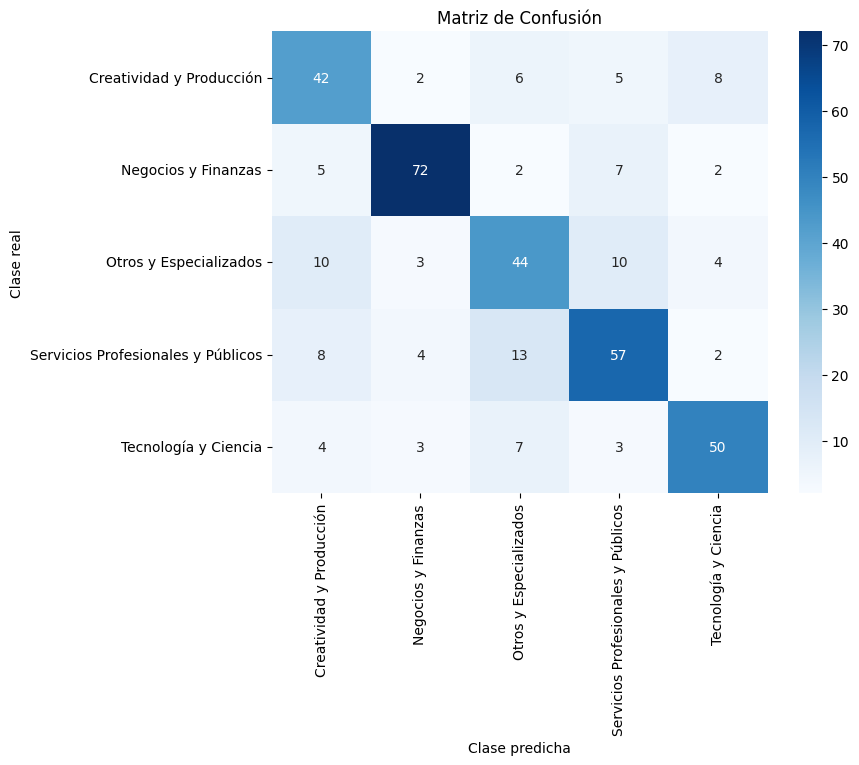

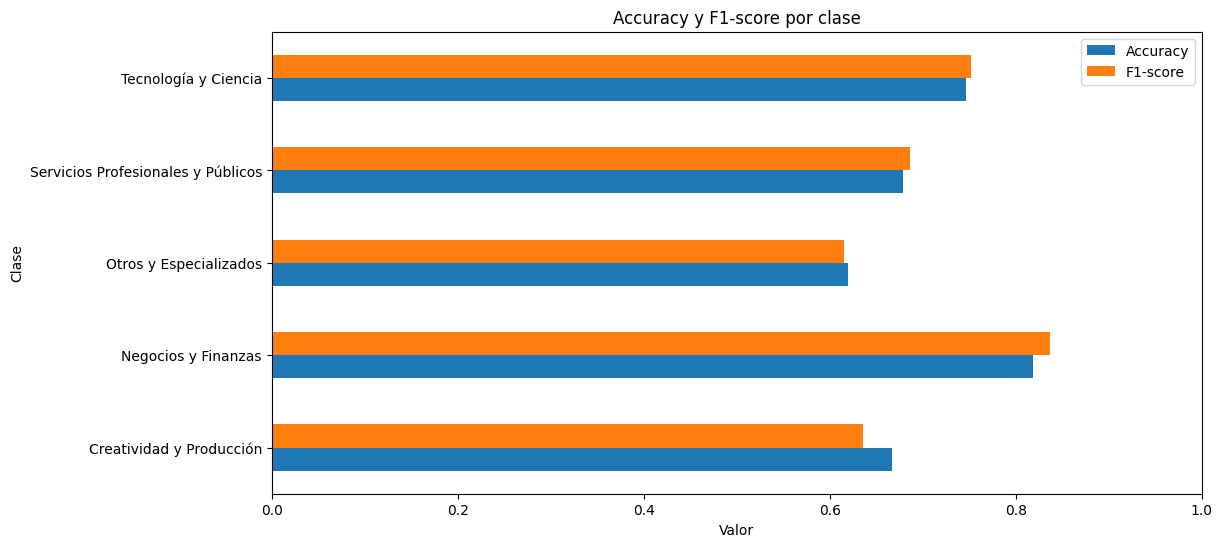

In [15]:
# Evaluación
# -------------------------
def get_predictions(loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device).long()
            outputs = model(X_batch)
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())
    return np.array(all_labels), np.array(all_preds)

print ("EVALUACION DEL MODELO")

# ---- Hiperparámetros ----
print("\n=== HIPERPARAMETROS DEL MODELO ===")
for k, v in params.items():
    print(f"{k}: {v}")

# ---- Validación ----
val_labels, val_preds = get_predictions(val_loader)
val_acc = accuracy_score(val_labels, val_preds)
val_f1 = f1_score(val_labels, val_preds, average='macro')
print("\n=== MÉTRICAS EN VALIDACIÓN ===")
print(f"Accuracy: {val_acc:.4f} | F1-macro: {val_f1:.4f}")

# ---- Test ----
test_labels, test_preds = get_predictions(test_loader)
test_acc = accuracy_score(test_labels, test_preds)
test_f1 = f1_score(test_labels, test_preds, average='macro')
print("\n=== MÉTRICAS EN TEST ===")
print(f"Accuracy: {test_acc:.4f} | F1-macro: {test_f1:.4f}")

# ---- Classification report ----
target_names = le.classes_
report = classification_report(test_labels, test_preds, target_names=target_names, zero_division=0, output_dict=True)
print("\n=== CLASSIFICATION REPORT (TEST) ===")
print(classification_report(test_labels, test_preds, target_names=target_names, zero_division=0))

# ---- Matriz de confusion ----
cm = confusion_matrix(test_labels, test_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=target_names, yticklabels=target_names, cmap="Blues")
plt.ylabel("Clase real")
plt.xlabel("Clase predicha")
plt.title("Matriz de Confusión")
plt.show()


# ---- Gráfico de métricas por clase (Acc y F1) ----
per_class_f1 = [report[label]['f1-score'] for label in target_names]
per_class_acc = [np.mean((test_preds[test_labels==i] == i)) for i, _ in enumerate(target_names)]

metrics_plot_df = pd.DataFrame({
    "Clase": target_names,
    "Accuracy": per_class_acc,
    "F1-score": per_class_f1
})

metrics_plot_df.set_index("Clase", inplace=True)
metrics_plot_df.plot(kind='barh', figsize=(12,6))  
plt.title("Accuracy y F1-score por clase")
plt.xlabel("Valor") 
plt.xlim(0,1)        
plt.yticks(rotation=0)  #
plt.show()


En cuanto al desempeño final, el modelo alcanzó un Accuracy de 0.7105 y un F1-macro de 0.7055 sobre el conjunto de test, lo cual evidencia un rendimiento equilibrado entre las clases. 

En el desglose por categoría, las mayores precisiones se observan en _Negocios y Finanzas_ (F1 = 0.84) y _Tecnología y Ciencia_ (F1 = 0.75), mientras que las categorías _Creatividad y Producción_ junto con _Otros y Especializados_ presentan desempeños moderados (F1 ≈ 0.62–0.64). 

Cabe notar que las métricas en validación (Accuracy 0.7688, F1-macro 0.7652) son superiores a las obtenidas en test; esa diferencia sugiere que el punto seleccionado durante entrenamiento ofrecía un ajuste algo optimista sobre el conjunto de validación y que el rendimiento real en datos no vistos (test) es ligeramente menor.

En términos generales, los resultados sugieren que el modelo logra capturar relaciones semánticas y contextuales relevantes entre los textos. Como se evidencia en el gráfico de barrars el equilibrio entre accuracy y F1 en la mayoría de las clases demuestra la competitividad del modelo para la tarea de clasificación de hojas de vida.

